# Statistical Anomaly Detection System

## Notebook 02: Exploratory Data Analysis

### Purpose

Exploratory analysis helps identify important patterns, relationships, and unusual observations within the air quality dataset.

### Objectives

- Examine pollutant distributions
- Investigate variable relationships
- Identify potential outliers
- Explore temporal trends
- Generate statistical insights

### Expected Outcome

A deeper understanding of the data structure and potential anomaly patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv(
    "/content/Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

pollutants = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

air_quality = df[pollutants].copy()

for col in pollutants:
    air_quality[col] = (
        air_quality[col]
        .fillna(
            air_quality[col].median()
        )
    )

air_quality.head()

,so2,no2,rspm,spm
0,4.8,17.4,80.0,173.0
1,3.1,7.0,80.0,173.0
2,6.2,28.5,80.0,173.0
3,6.3,14.7,80.0,173.0
4,4.7,7.5,80.0,173.0


## Distribution Analysis

Understanding pollutant distributions is essential because anomaly detection methods are heavily influenced by data shape, skewness, and extreme values.

In [4]:
air_quality.describe()

,so2,no2,rspm,spm
count,224220.000000,224220.000000,224220.000000,224220.000000
mean,10.078066,22.031293,93.468577,185.777227
std,9.531068,14.894833,61.949765,97.569956
min,0.000000,0.000000,0.000000,0.000000
25%,4.400000,13.000000,56.000000,168.000000
50%,7.200000,18.800000,80.000000,173.000000
75%,13.000000,27.300000,112.000000,179.000000
max,273.300000,696.000000,1082.000000,2213.000000


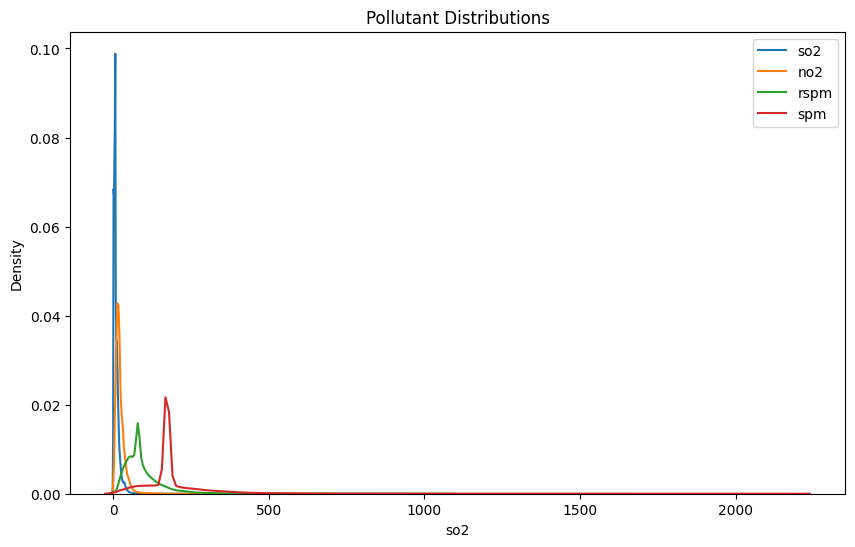

In [5]:
plt.figure(figsize=(10,6))

for column in pollutants:

    sns.kdeplot(
        air_quality[column],
        label=column
    )

plt.title(
    "Pollutant Distributions"
)

plt.legend()

plt.savefig(
    "images/pollutant_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships among pollutants and provides insight into multivariate dependence structures.

In [6]:
correlation_matrix = (
    air_quality
    .corr()
)

correlation_matrix

,so2,no2,rspm,spm
so2,1.000000,0.423072,0.167326,0.163301
no2,0.423072,1.000000,0.403485,0.303196
rspm,0.167326,0.403485,1.000000,0.480146
spm,0.163301,0.303196,0.480146,1.000000


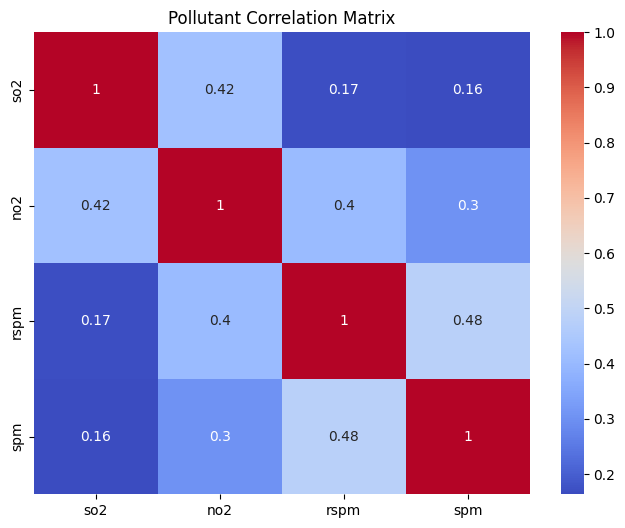

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Pollutant Correlation Matrix"
)

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Outlier Exploration

Boxplots provide a visual summary of potential extreme observations and distributional characteristics.

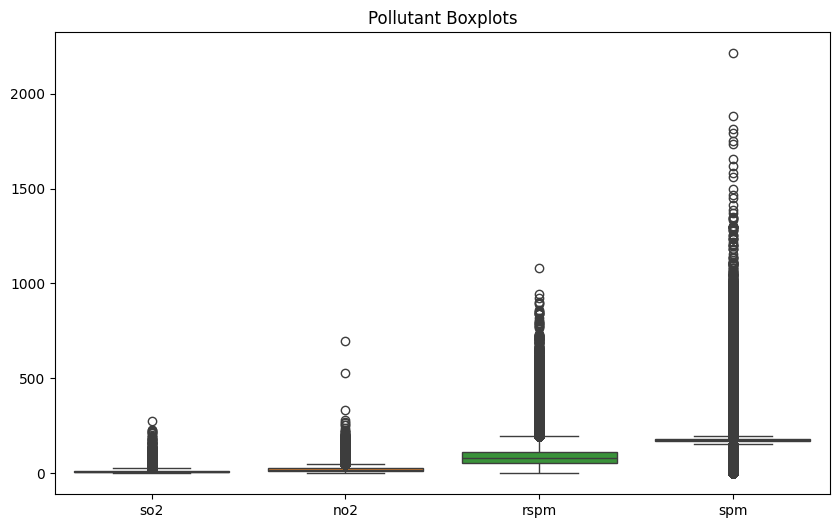

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=air_quality
)

plt.title(
    "Pollutant Boxplots"
)

plt.savefig(
    "images/pollutant_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df["year"] = (
    df["date"]
    .dt.year
)

In [10]:
annual_trend = (
    df.groupby("year")
    ["rspm"]
    .mean()
)

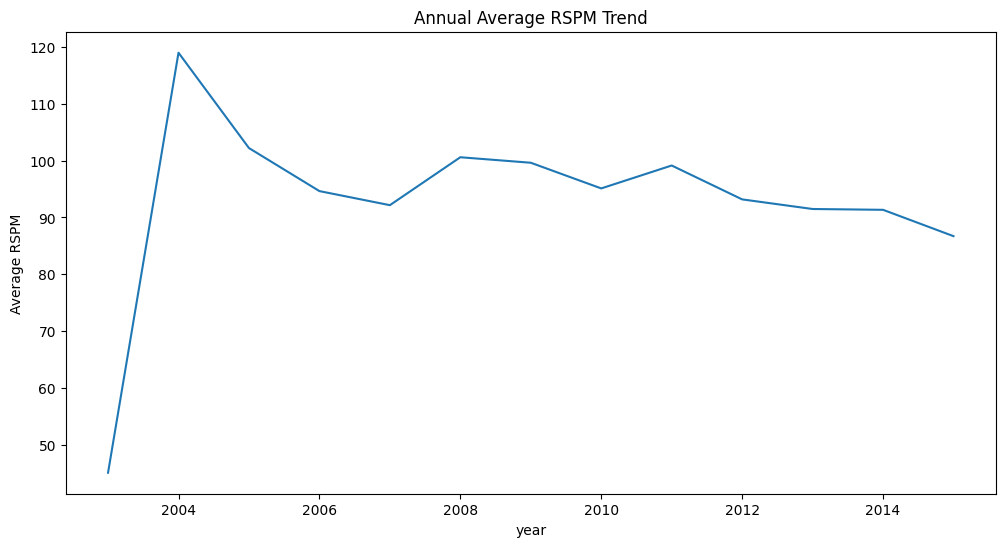

In [11]:
plt.figure(figsize=(12,6))

annual_trend.plot()

plt.title(
    "Annual Average RSPM Trend"
)

plt.ylabel(
    "Average RSPM"
)

plt.savefig(
    "images/annual_pollution_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Findings

The exploratory analysis revealed substantial variation across pollutant concentrations and evidence of skewed distributions.

Correlation analysis suggested meaningful relationships among several pollutants, indicating that multivariate approaches may be valuable for anomaly detection.

Boxplots highlighted the presence of extreme observations, motivating the use of robust statistical methods in subsequent analyses.

Temporal trends further demonstrated the dynamic nature of air quality measurements and the potential for detecting unusual environmental conditions.

In [12]:
import os

print(os.listdir("images"))

['annual_pollution_trend.png', 'correlation_heatmap.png', 'pollutant_boxplots.png', 'pollutant_distribution.png']
